In [ ]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import csv

# folder_path = os.path.join("../data_for_plots",
#                            "moving_vs_resting_bubble",
#                            "line_data_rho%s_v%s_circular_Ux%s" % (rho_ratio, v,Ux))

rho_ratio = '1'
v = '01'
U='001'

folder_path = os.path.join("~/DATA_FOR_PLOTS",
                           "moving_vs_resting_bubble","old",
                           f"line_data_rho{rho_ratio}_v{v}_circular_U{U}")

n = 999  # last time-frame

cm_ux_std = np.empty(n)
mrt_ux_std = np.empty(n)

frames_cm_resting = []
frames_mrt_resting = []
frames_cm_moving = []
frames_mrt_moving = []

U0 = 0.01  # mean flow velocity

for i in range(n):
    frame_cm_resting = pd.read_csv(os.path.join(folder_path, "cm_resting.%d.csv" % i), delimiter="\t")
    frame_mrt_resting = pd.read_csv(os.path.join(folder_path, "mrt_resting.%d.csv" % i), delimiter="\t")
    frame_cm_moving = pd.read_csv(os.path.join(folder_path, "cm_moving.%d.csv" % i), delimiter="\t")
    frame_mrt_moving = pd.read_csv(os.path.join(folder_path, "mrt_moving.%d.csv" % i), delimiter="\t")

    frames_cm_resting.append(frame_cm_resting)
    frames_mrt_resting.append(frame_mrt_resting)
    frames_cm_moving.append(frame_cm_moving)
    frames_mrt_moving.append(frame_mrt_moving)

    cm_ux_std[i] = np.sqrt(sum((frame_cm_moving['U:0'] - U0) * (frame_cm_moving['U:0'] - U0)) / len(frame_cm_moving['U:0']))
    mrt_ux_std[i] = np.sqrt(sum((frame_mrt_moving['U:0'] - U0) * (frame_mrt_moving['U:0'] - U0)) / len(frame_mrt_moving['U:0']))

    
#     frame_cm = pd.read_csv(os.path.join(folder_path, "cm_moving.%d.csv" % i), delimiter="\t")
#     frame_mrt = pd.read_csv(os.path.join(folder_path, "mrt_moving.%d.csv" % i), delimiter="\t")

#     frames_cm_moving.append(frame_cm)
#     frames_mrt_moving.append(frame_mrt)

#     cm_ux_std[i] = np.sqrt(sum((frame_cm['U:0'] - U0) * (frame_cm['U:0'] - U0)) / len(frame_cm['U:0']))
#     mrt_ux_std[i] = np.sqrt(sum((frame_mrt['U:0'] - U0) * (frame_mrt['U:0'] - U0)) / len(frame_mrt['U:0']))

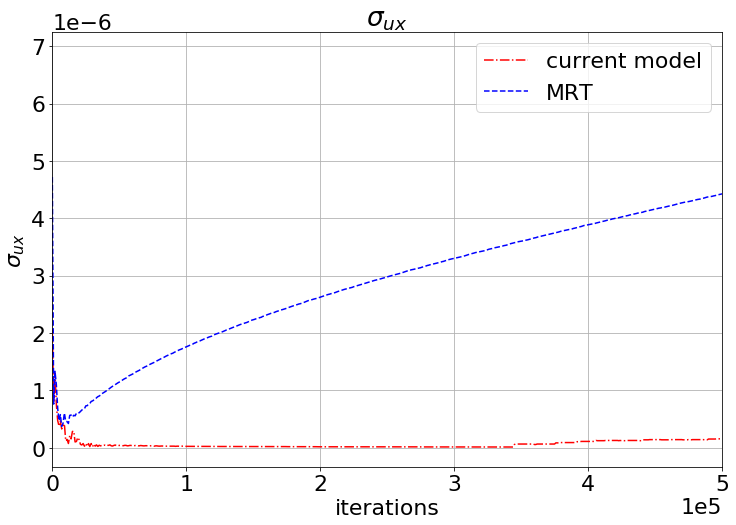

In [24]:
## make plot
plt.rcParams.update({'font.size': 22})
plt.figure(figsize=(12, 8))
plt.plot(np.arange(n)*1E3, cm_ux_std,  color="red",  marker="", linestyle="-.", label=r'current model')
plt.plot(np.arange(n)*1E3, mrt_ux_std, color="blue", marker="", linestyle="--", label=r'MRT')
# plt.plot(line_size, theoretical, color="black", marker="x", linestyle="", label='theoretical')

# plt.plot(frames_cm[150]['arc_length'], frames_cm[150]['U:0'],  color="red",  marker="<", linestyle="", label=r'current model')
# plt.plot(frames_mrt[150]['arc_length'], frames_mrt[150]['U:0'], color="blue", marker=">", linestyle="", label=r'MRT')

axes = plt.gca()
axes.set_xlim([0,0.5*1E6])
# axes.set_ylim([0, 1.0])

# plt.plot(frames_cm[0]['arc_length'], frames_cm[0]['PhaseField'], color="green", marker="x", linestyle="",  label='test')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.ylabel(r'$\sigma_{ux}$')
plt.xlabel(r'iterations')

plt.title(r'$\sigma_{ux}$ ')
plt.grid(True)
plt.legend()

fig = plt.gcf()  # get current figure
fig.savefig('sigma_ux_rho%s_v%s_Ux%s.png' % (rho_ratio, v, Ux))
plt.show()
plt.close(fig) # close the figure